# Stellar parameters from the TSLTE pre-integrated photometry grid

The real thing: `TSLTE_combined_photometry.fits` (A. Chiti's Turbospectrum LTE
synthetic photometry — the MAGIC grid) loaded into tengri-stars, a mock star
drawn from it, and the full posterior workflow of notebook 01 — NSS and NUTS
side by side — on pre-filter-integrated magnitudes. No wavelength integral
anywhere: fit-time photometry is one differentiable grid lookup.

Get the grid (from a Sherlock login):
```bash
scp <sunetid>@login.sherlock.stanford.edu:\
    /oak/stanford/orgs/kipac/users/achiti/grid/TSLTE_combined_photometry.fits \
    ~/Projects/tengri-stars/data/
```

In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # silence XLA/PJRT C++ chatter

import time
from pathlib import Path

# Notebook kernels launch in notebooks/; scripts run from the repo root.
DATA = (
    Path("data") if (Path("data") / "TSLTE_combined_photometry.fits").exists() else Path("../data")
)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tengri import Uniform

from tengri_stars import StarModel, fit_nss, fit_nuts, load_photometry_grid, overlay_corner

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(17)

GRID_PATH = DATA / "TSLTE_combined_photometry.fits"

## 1. Load the grid

The loader prefers `averaged=True` rows on duplicate nodes and rejects the
duplicated label columns (`Teff_1`, `[Fe/H]_1`, ...). Synthetic grids are
rarely perfect boxes, so fall back to nearest-neighbor hole filling and keep
the coverage mask.

In [2]:
try:
    grid = load_photometry_grid(GRID_PATH)
except ValueError as err:
    print(f"strict load: {err}\n→ retrying with fill='nearest'")
    grid = load_photometry_grid(GRID_PATH, fill="nearest")

n_teff, n_logg, n_feh = (a.shape[0] for a in grid.axes)
covered = float(grid.coverage.mean())
print(f"axes: {n_teff} Teff × {n_logg} logg × {n_feh} [Fe/H] nodes, {covered:.1%} covered")
print(f"Teff  [{float(grid.axes[0][0]):7.0f}, {float(grid.axes[0][-1]):7.0f}] K")
print(f"logg  [{float(grid.axes[1][0]):7.2f}, {float(grid.axes[1][-1]):7.2f}]")
print(f"[Fe/H][{float(grid.axes[2][0]):7.2f}, {float(grid.axes[2][-1]):7.2f}]")
print(f"{len(grid.filter_names)} filters: {grid.filter_names}")

strict load: 1750/6240 grid nodes missing from the table (non-rectangular coverage). Pass fill='nearest' to fill holes and track them via PhotometryGrid.coverage.
→ retrying with fill='nearest'


axes: 32 Teff × 13 logg × 15 [Fe/H] nodes, 72.0% covered
Teff  [   2500,    8000] K
logg  [  -0.50,    5.50]
[Fe/H][  -5.00,    1.00]
21 filters: ('lsst_g_ab', 'skymapper_i_ab', 'HST_WFC3_UVIS1.F336W_ab', 'SLOAN-SDSS.i_ab', 'DECCAM_i_des_ab', 'HST_ACS_WFC.F475W_ab', 'DECCAM_u_des_ab', 'SLOAN-SDSS.g_ab', 'skymapper_g_ab', 'CaHK_filter_ab', 'HST_ACS_WFC.F814W_ab', 'lsst_u_ab', 'DECCAM_r_des_ab', 'lsst_i_ab', 'DECCAM_g_des_ab', 'skymapper_u_ab', 'SLOAN-SDSS.r_ab', 'skymapper_r_ab', 'SLOAN-SDSS.u_ab', 'lsst_r_ab', 'skymapper_v_ab')


## 2. Coverage map

Fraction of [Fe/H] nodes present per (Teff, log g) cell — the white regions are
where `fill='nearest'` extrapolated and posteriors should not be trusted.

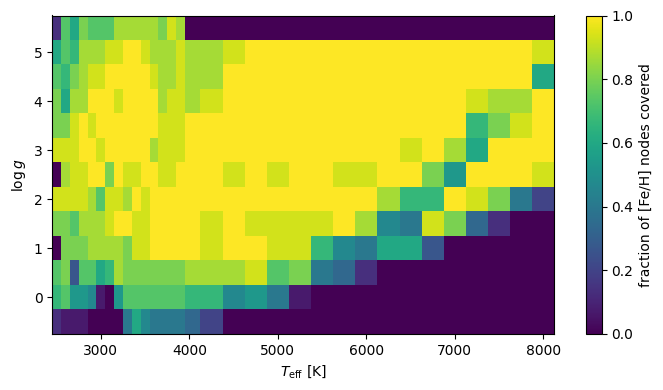

In [3]:
frac = np.asarray(grid.coverage).mean(axis=2)
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.pcolormesh(
    np.asarray(grid.axes[0]),
    np.asarray(grid.axes[1]),
    frac.T,
    cmap="viridis",
    vmin=0,
    vmax=1,
    shading="nearest",
)
fig.colorbar(im, label="fraction of [Fe/H] nodes covered")
ax.set(xlabel=r"$T_{\rm eff}$ [K]", ylabel=r"$\log g$")
plt.tight_layout()
plt.show()

## 3. Filters and a mock star

Edit `FILTERS_USE` to the survey combination you care about (default: all
columns in the file). The mock star sits at interior grid values; magnitudes
get survey-like noise and the dilution μ shifts them to apparent scale.

In [4]:
FILTERS_USE = list(grid.filter_names)  # e.g. ["lsst_g_ab", "skymapper_v_ab", "cahk", ...]
fidx = jnp.asarray([grid.filter_names.index(f) for f in FILTERS_USE])

model = StarModel(grid=grid, interp_method="pchip")

TRUTH = {
    "teff": float(np.median(np.asarray(grid.axes[0]))),
    "logg": float(np.asarray(grid.axes[1])[n_logg // 3]),
    "feh": float(np.asarray(grid.axes[2])[n_feh // 3]),
    "mu": -18.0,  # grid zero-point → apparent-mag offset, absorbed by the fit
}
SIG_MAG = 0.02

mags_clean = model.predict_mags(**TRUTH)[fidx]
mags_obs = jnp.asarray(np.asarray(mags_clean) + rng.normal(0.0, SIG_MAG, len(FILTERS_USE)))
print("mock star:", {k: round(v, 2) for k, v in TRUTH.items()})
print("observed mags:", dict(zip(FILTERS_USE, np.round(np.asarray(mags_obs), 2))))

mock star: {'teff': 4125.0, 'logg': 1.5, 'feh': -1.5, 'mu': -18.0}
observed mags: {'lsst_g_ab': np.float64(10.65), 'skymapper_i_ab': np.float64(9.23), 'HST_WFC3_UVIS1.F336W_ab': np.float64(12.93), 'SLOAN-SDSS.i_ab': np.float64(9.25), 'DECCAM_i_des_ab': np.float64(9.17), 'HST_ACS_WFC.F475W_ab': np.float64(10.69), 'DECCAM_u_des_ab': np.float64(12.58), 'SLOAN-SDSS.g_ab': np.float64(10.75), 'skymapper_g_ab': np.float64(10.37), 'CaHK_filter_ab': np.float64(12.46), 'HST_ACS_WFC.F814W_ab': np.float64(9.13), 'lsst_u_ab': np.float64(12.66), 'DECCAM_r_des_ab': np.float64(9.57), 'lsst_i_ab': np.float64(9.31), 'DECCAM_g_des_ab': np.float64(10.64), 'skymapper_u_ab': np.float64(12.84), 'SLOAN-SDSS.r_ab': np.float64(9.73), 'skymapper_r_ab': np.float64(9.73), 'SLOAN-SDSS.u_ab': np.float64(12.78), 'lsst_r_ab': np.float64(9.69), 'skymapper_v_ab': np.float64(12.5)}


## 4. Fit: NSS and NUTS on the same posterior

In [5]:
lo_hi = [(float(a[0]), float(a[-1])) for a in grid.axes]
priors = {
    "teff": Uniform(*lo_hi[0]),
    "logg": Uniform(*lo_hi[1]),
    "feh": Uniform(*lo_hi[2]),
    "mu": Uniform(TRUTH["mu"] - 10.0, TRUTH["mu"] + 10.0),
}


def loglikelihood(p):
    pred = model.predict_mags(teff=p["teff"], logg=p["logg"], feh=p["feh"], mu=p["mu"])[fidx]
    return -0.5 * jnp.sum(((pred - mags_obs) / SIG_MAG) ** 2)


t0 = time.time()
nss = fit_nss(loglikelihood, priors, key=jax.random.PRNGKey(2), n_live=400, num_delete=40)
print(f"NSS:  {time.time() - t0:5.1f} s  log Z = {nss.logz:.1f}  ESS = {nss.ess:.0f}")

t0 = time.time()
nuts = fit_nuts(loglikelihood, priors, key=jax.random.PRNGKey(3), num_warmup=800, num_samples=1500)
print(
    f"NUTS: {time.time() - t0:5.1f} s  acceptance {nuts.acceptance_rate:.2f}, "
    f"{nuts.num_divergent} divergences"
)

NSS:    4.4 s  log Z = -31.5  ESS = 1939


NUTS:  10.4 s  acceptance 0.93, 0 divergences


## 5. Posteriors

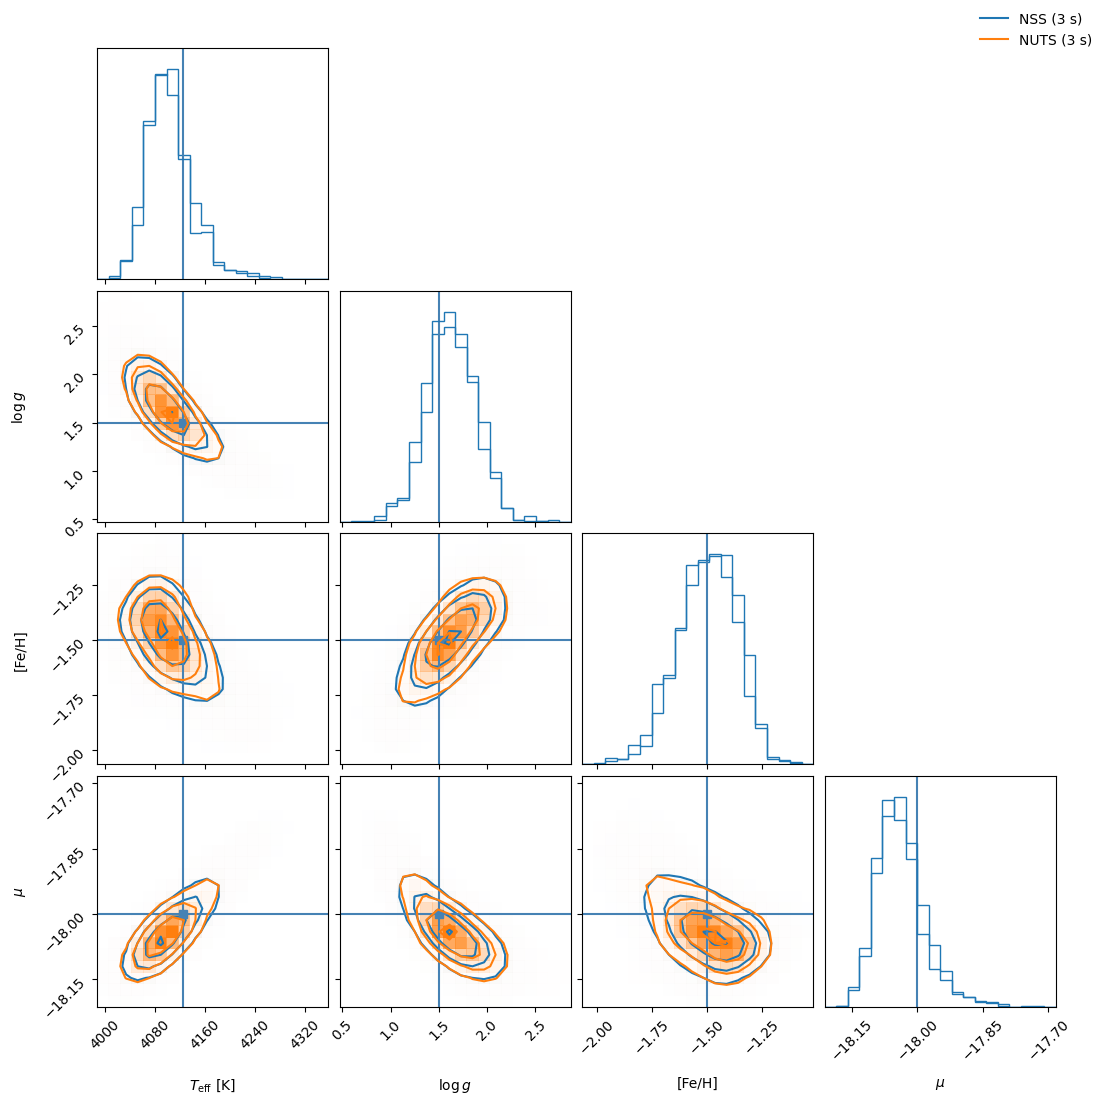

          truth  NSS median          68% interval
teff    4125.00     4101.20      [ 4070.87,  4139.52]
logg       1.50        1.61      [    1.37,     1.87]
feh       -1.50       -1.50      [   -1.64,    -1.37]
mu       -18.00      -18.04      [  -18.09,   -17.99]


In [6]:
names = list(priors)
labels_tex = [r"$T_{\rm eff}$ [K]", r"$\log g$", "[Fe/H]", r"$\mu$"]
truth_vec = [TRUTH[n] for n in names]

fig = overlay_corner(
    [nss.samples, nuts.samples],
    names=names,
    labels=labels_tex,
    colors=["C0", "C1"],
    legend_labels=[f"NSS ({nss.wall_time:.0f} s)", f"NUTS ({nuts.wall_time:.0f} s)"],
    truths=TRUTH,
)
plt.show()

med, ci = nss.median(), nss.interval(0.68)
print(f"{'':6s}{'truth':>9s}{'NSS median':>12s}{'68% interval':>22s}")
for n in names:
    print(f"{n:6s}{TRUTH[n]:9.2f}{med[n]:12.2f}      [{ci[n][0]:8.2f}, {ci[n][1]:8.2f}]")

## Next steps on real data

- **Real stars**: replace the mock block with catalog magnitudes (DELVE/Gaia
  cross-match) and per-band errors; add SFD dereddening (0.65 × E(B−V)) via
  per-filter reddening coefficients (`StarModel(extinction_coeffs=...)`).
- **Convention audit**: recompute a few grid magnitudes from raw TSLTE spectra
  through tengri's filter integration (photon-counting 1/λ default) and compare
  against the FITS values before mixing this grid with other filter sets.
- **`averaged` flag**: confirm semantics with Ani — the loader currently
  prefers `averaged=True` rows when nodes are duplicated.